In [1]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_case_data_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(4950, 8)


In [2]:
# remove model_name == 'Random'


In [3]:
import re
def case_name_split(case_name_list):
    pattern = r'(\w+)k-(\w+)seg-(\w+)'
    case_name_split_list = []
    for case_name in case_name_list:
        match = re.match(pattern, case_name)
        if match:
            case_split = match.groups()
            case_split = [int(case_split[0])*1000, int(case_split[1]), case_split[2]]
            case_name_split_list.append(case_split)
        else:
            print(f"Pattern not matched for {case_name}")
    return case_name_split_list

case_name_list = data['case_name']
case_name_split_list = case_name_split(case_name_list)
case_data = pd.DataFrame(case_name_split_list, columns=['ts_len', 'seg', 'seg_type'])
# merge the new columns with the original data
print(data.shape, case_data.shape)
# data_new = pd.merge(data, case_data, on='case_name', how='left')
data_new = pd.concat([data, case_data], axis=1)
data_new = data_new[data_new['model_name'] != 'Random']
print(data_new.shape)

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    '20L', '20H', '50L', '50H', '100L', '100H', '500L', '500H',
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx


print(data_new.head())
print(data_new.columns)

(4950, 8) (4950, 3)
(4500, 11)
          case_name model_name  case_seed metric_name  mean_val   std_val  \
0  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
1  100k-100seg-100H    Model10         53     AUC-ROC  0.100225  0.002738   
2  100k-100seg-100H    Model10         53      Aff-F1  0.599683  0.008507   
3  100k-100seg-100H    Model10         53          F1  0.007339  0.000856   
4  100k-100seg-100H    Model10         53       F1-PA  0.511857  0.041889   

   mean_latency  std_latency  ts_len  seg seg_type  
0     21.221560     0.059661  100000  100     100H  
1     28.568022     0.162600  100000  100     100H  
2    808.004104     2.556749  100000  100     100H  
3     38.742157     0.227650  100000  100     100H  
4     99.825350     0.573268  100000  100     100H  
Index(['case_name', 'model_name', 'case_seed', 'metric_name', 'mean_val',
       'std_val', 'mean_latency', 'std_latency', 'ts_len', 'seg', 'seg_type'],
      dtype='object')


In [4]:
# todo
# import matplotlib.pyplot as plt
# import seaborn as sns
# # 1. 相同长度下，不同指标的latency分布图
# def plot_latency_distribution(data, ts_len):
    

#     filtered_data = data[data['ts_len'] == ts_len]
#     metric_names = filtered_data['metric_name'].unique()
#     for metric in metric_names:
#         metric_data = filtered_data[filtered_data['metric_name'] == metric]
#         metric_data = metric_data.sort_values(by=['seg_type'], key=lambda x: x.apply(sort_seg_type_key))
#         # metric_latency = metric_data['mean_latency']
#         plt.figure(figsize=(4, 6))
#         sns.boxplot(x='seg_type', y='mean_latency', data=metric_data)
#         plt.title(f'Latency Distribution for ts_len = {ts_len}, Metric = {metric}')
#         plt.xlabel('Segment Type')
#         plt.ylabel('Latency')
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

# plot_latency_distribution(data_new, 10000)  # Example for ts_len = 1000


/tmp/ipykernel_3934153/2856471156.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric   Avg. Latency   Std. Latency  Avg. Latency per point
0           F1      49.731705      30.958940                0.000497
1        F1-PA     116.257763      56.594961                0.001163
2   Reduced-F1     127.330697      49.697679                0.001273
3         PA%K   10276.396757    2398.830340                0.102764
4   R-based F1     453.840749     203.481744                0.004538
5         TaPR    5325.436673    7364.843544                0.053254
6        eTaPR    3658.017929    4880.927021                0.036580
7       Aff-F1    1013.389730    1315.975648                0.010134
8      NAff-F1     984.575416    1195.117425                0.009846
9      UAff-F1     984.689680    1160.497364                0.009847
10        PATE  206472.352598  228602.762025                2.064724
11     AUC-ROC      41.681524      39.069794                0.000417
12      AUC-PR      26.355353      18.300977                0.000264
13     VUS-ROC   22228.319713   23

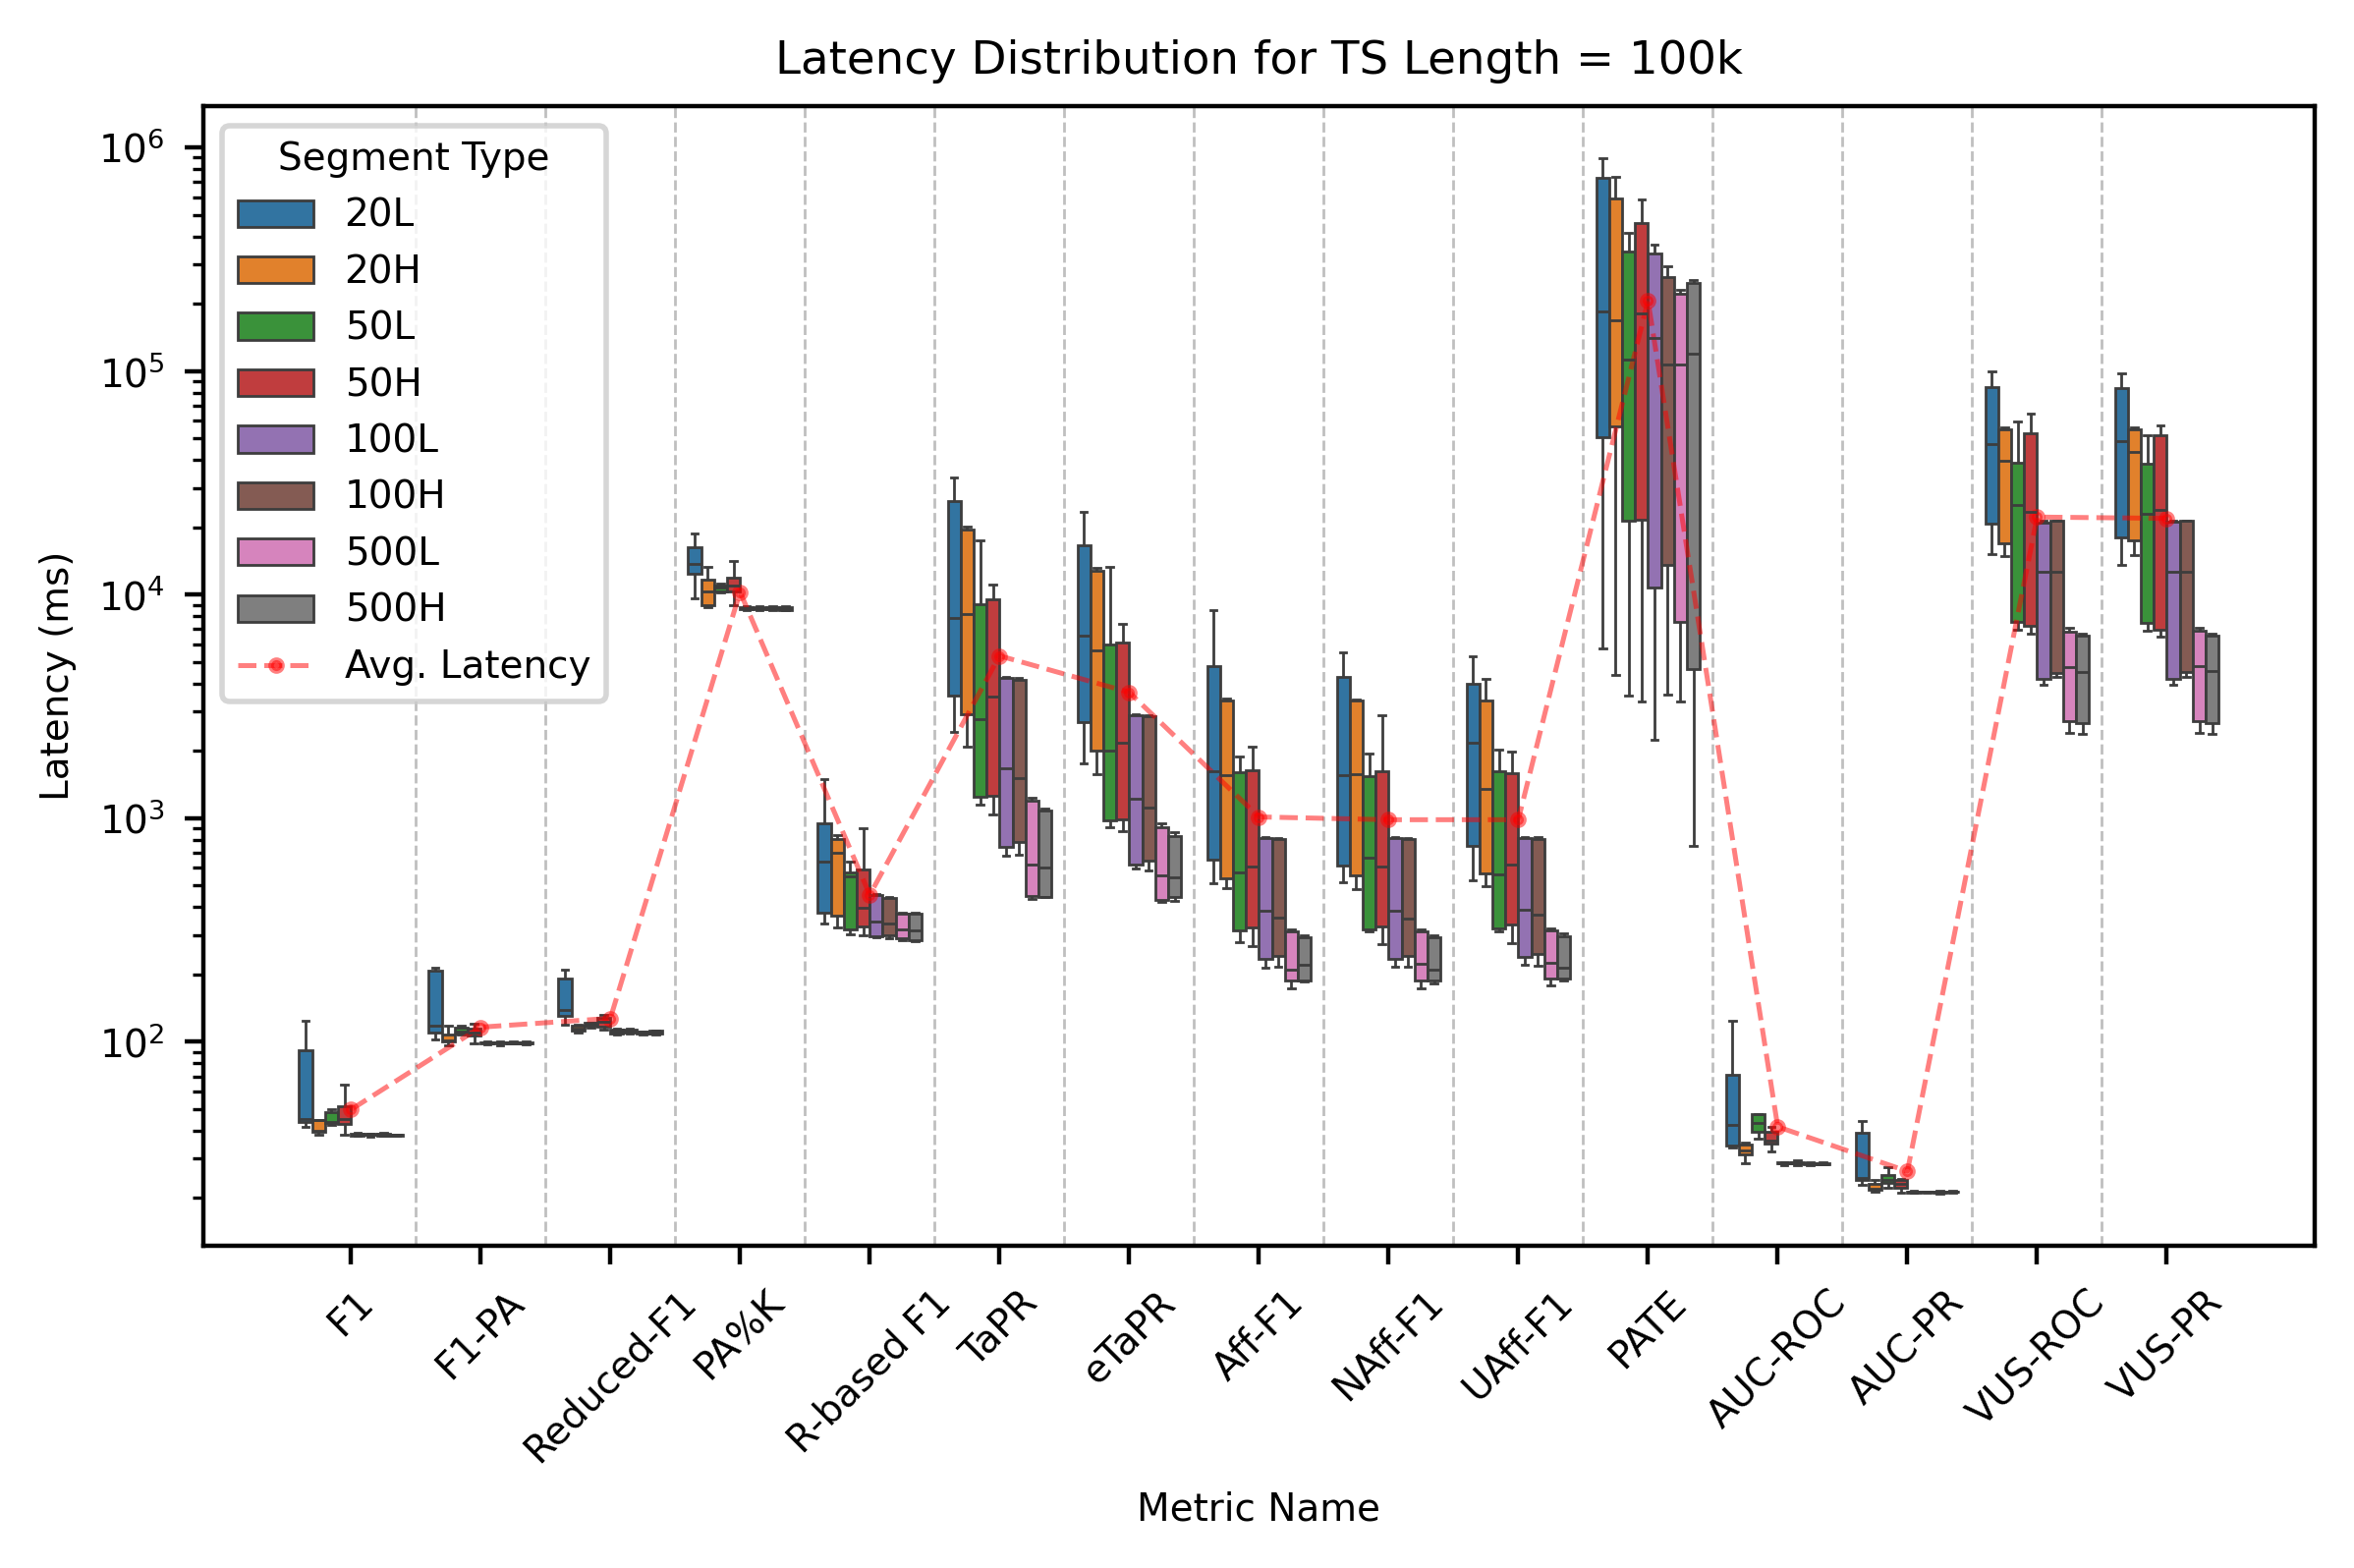

/tmp/ipykernel_3934153/2856471156.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric  Avg. Latency  Std. Latency  Avg. Latency per point
0           F1      4.043010      0.039195                0.000404
1        F1-PA     10.499730      0.988521                0.001050
2   Reduced-F1     11.419109      0.355936                0.001142
3         PA%K    913.490577     13.018613                0.091349
4   R-based F1     31.488998      2.785682                0.003149
5         TaPR     84.383415     61.284025                0.008438
6        eTaPR     68.671093     39.057483                0.006867
7       Aff-F1     25.830829     10.770715                0.002583
8      NAff-F1     25.851462     10.767149                0.002585
9      UAff-F1     26.143383     10.760278                0.002614
10        PATE   3172.524669   2748.787861                0.317252
11     AUC-ROC      3.744696      1.184872                0.000374
12      AUC-PR      2.248936      0.059728                0.000225
13     VUS-ROC   1985.138467   1823.696923                0.19

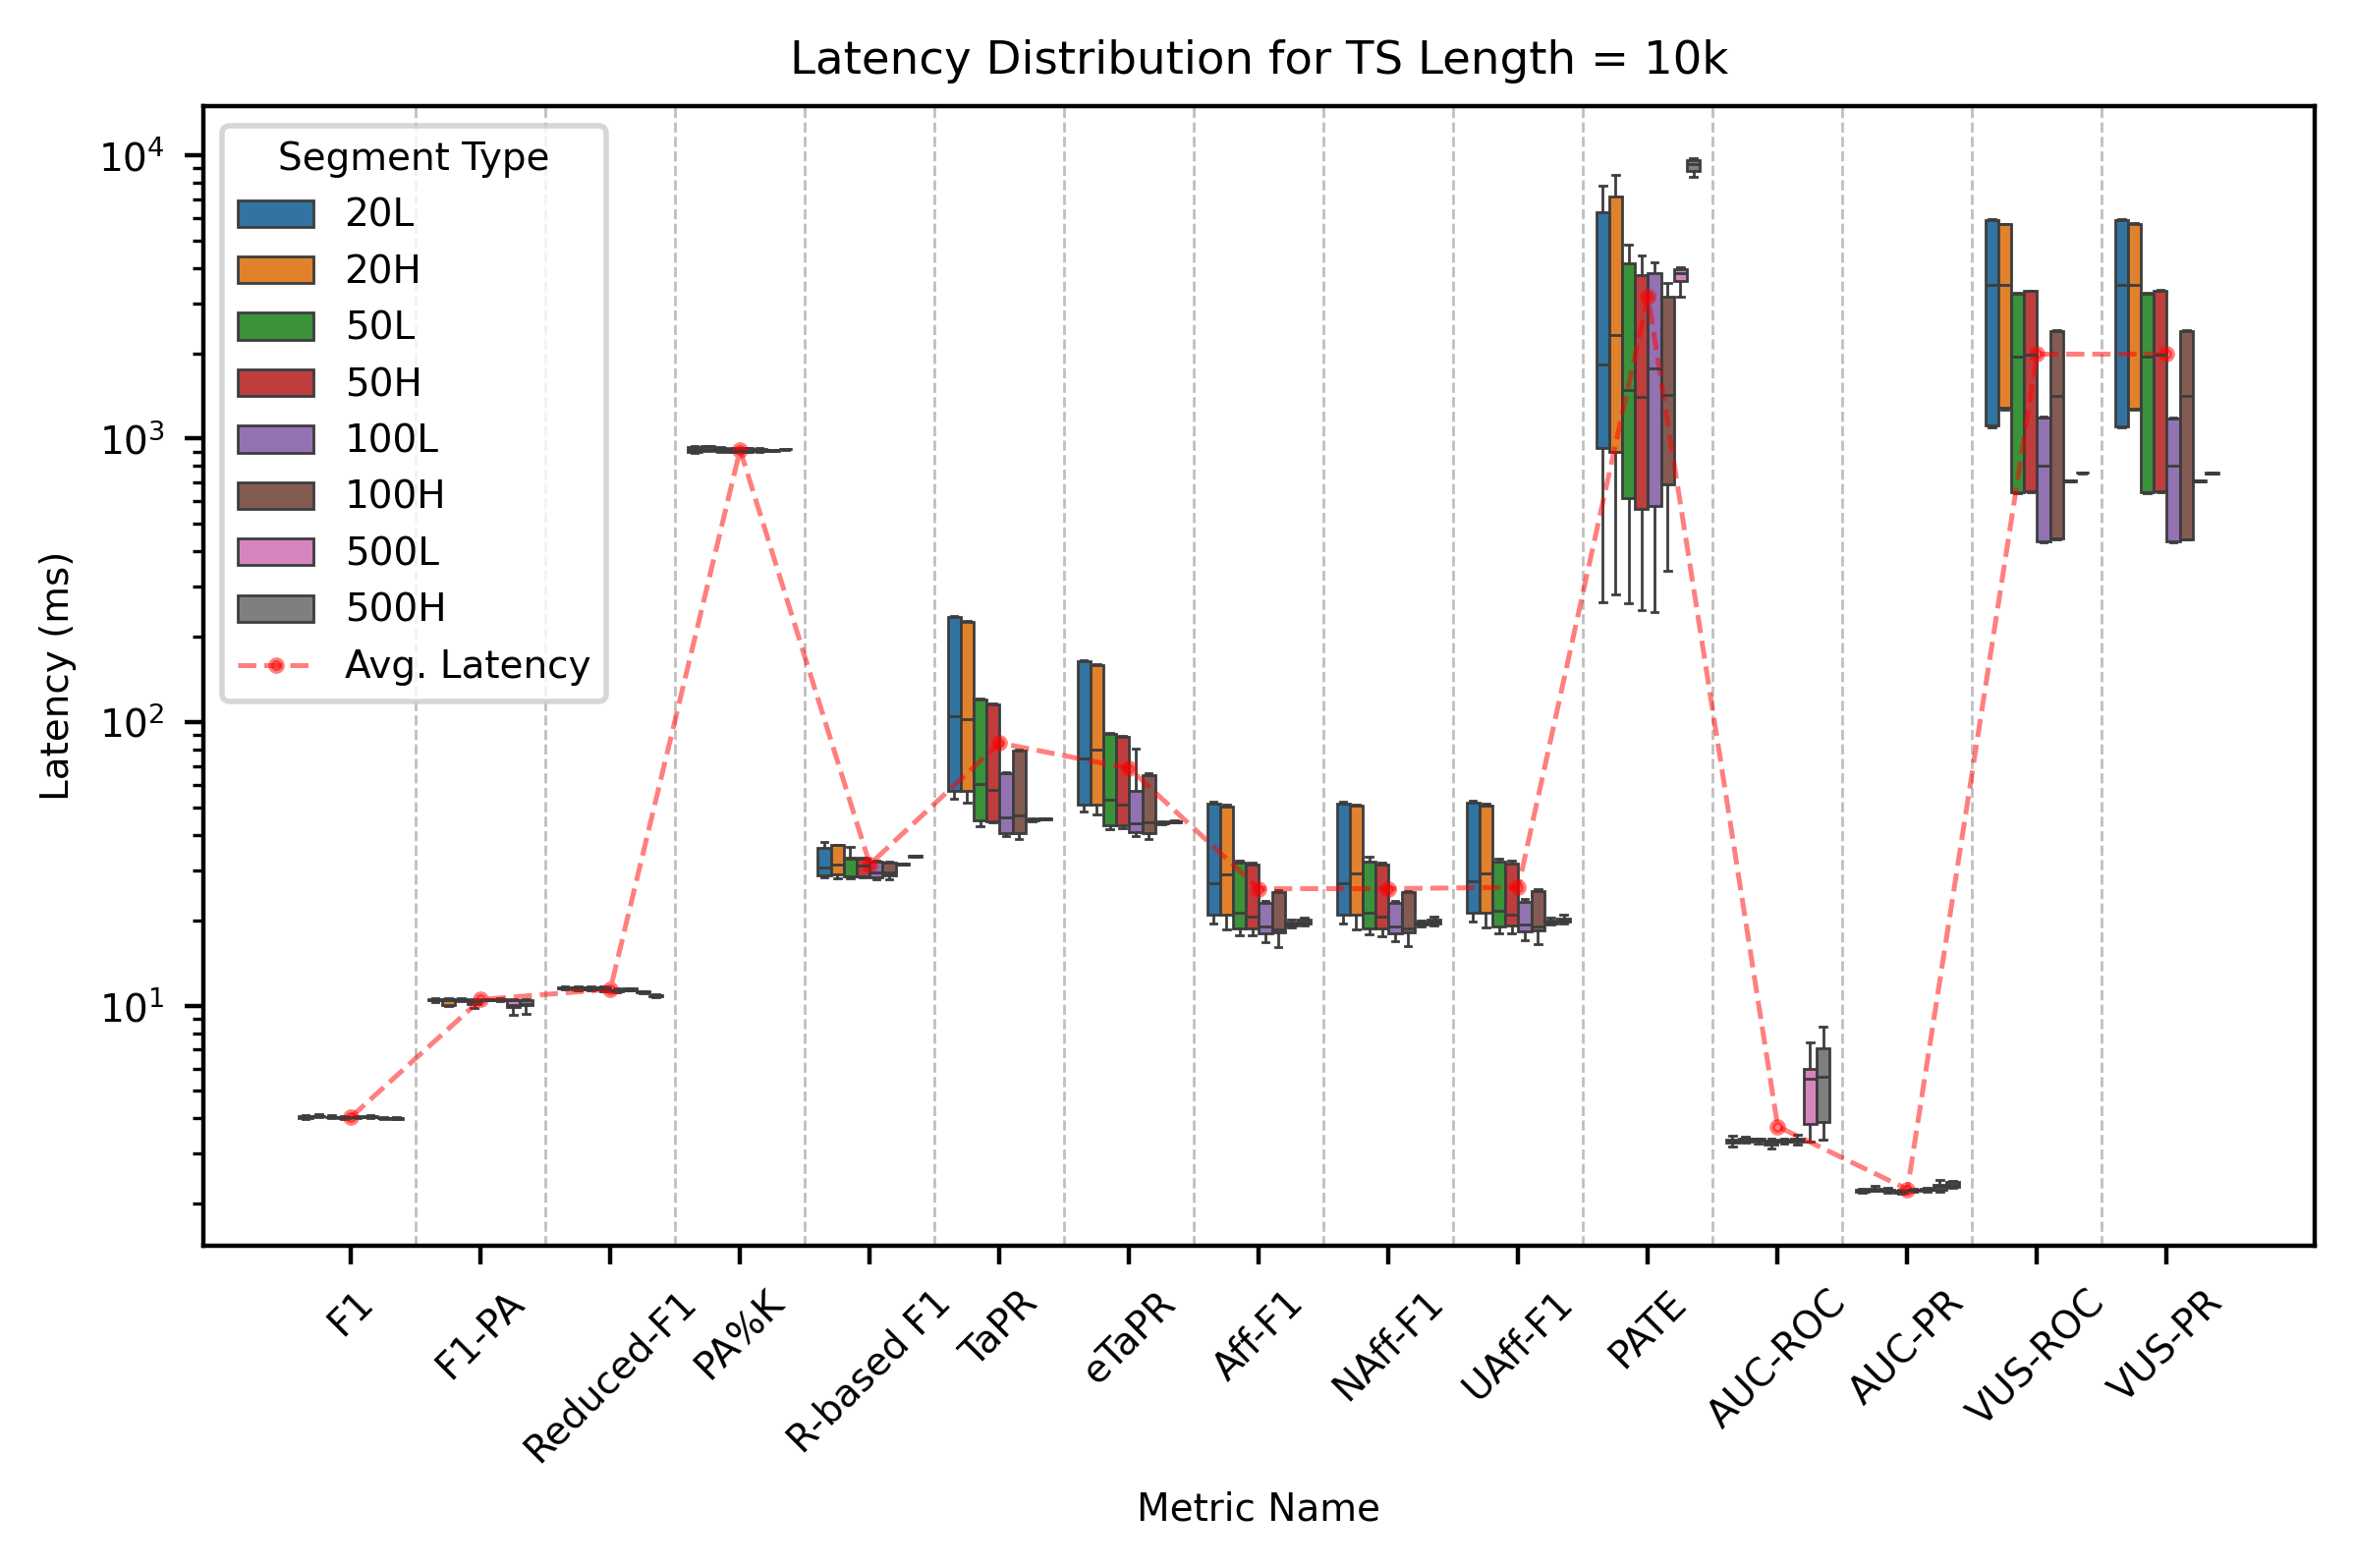

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_latency'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_latency'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    out_pth = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}.csv'
    # 转置
    saving_df = pd.merge(mean_values, std_values, on='metric_name', suffixes=('_mean', '_std'))
    saving_df.columns = ['Metric', 'Avg. Latency', 'Std. Latency']
    saving_df['Avg. Latency per point'] = saving_df['Avg. Latency'] / ts_len
    print(saving_df)
    saving_df.to_csv(out_pth, index=False)
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    mean_values = mean_values.to_numpy()
    plt.plot(mean_values[:, 0], mean_values[:, 1], color='red', marker='o', markersize=2, label='Avg. Latency'
             , linestyle='--', linewidth=0.9,
            #  透明度
                alpha=0.5
             )
    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    
        
    plt.legend(title='Segment Type')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/seg_len_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

[100  10 200  20   2 500  50   1   5]


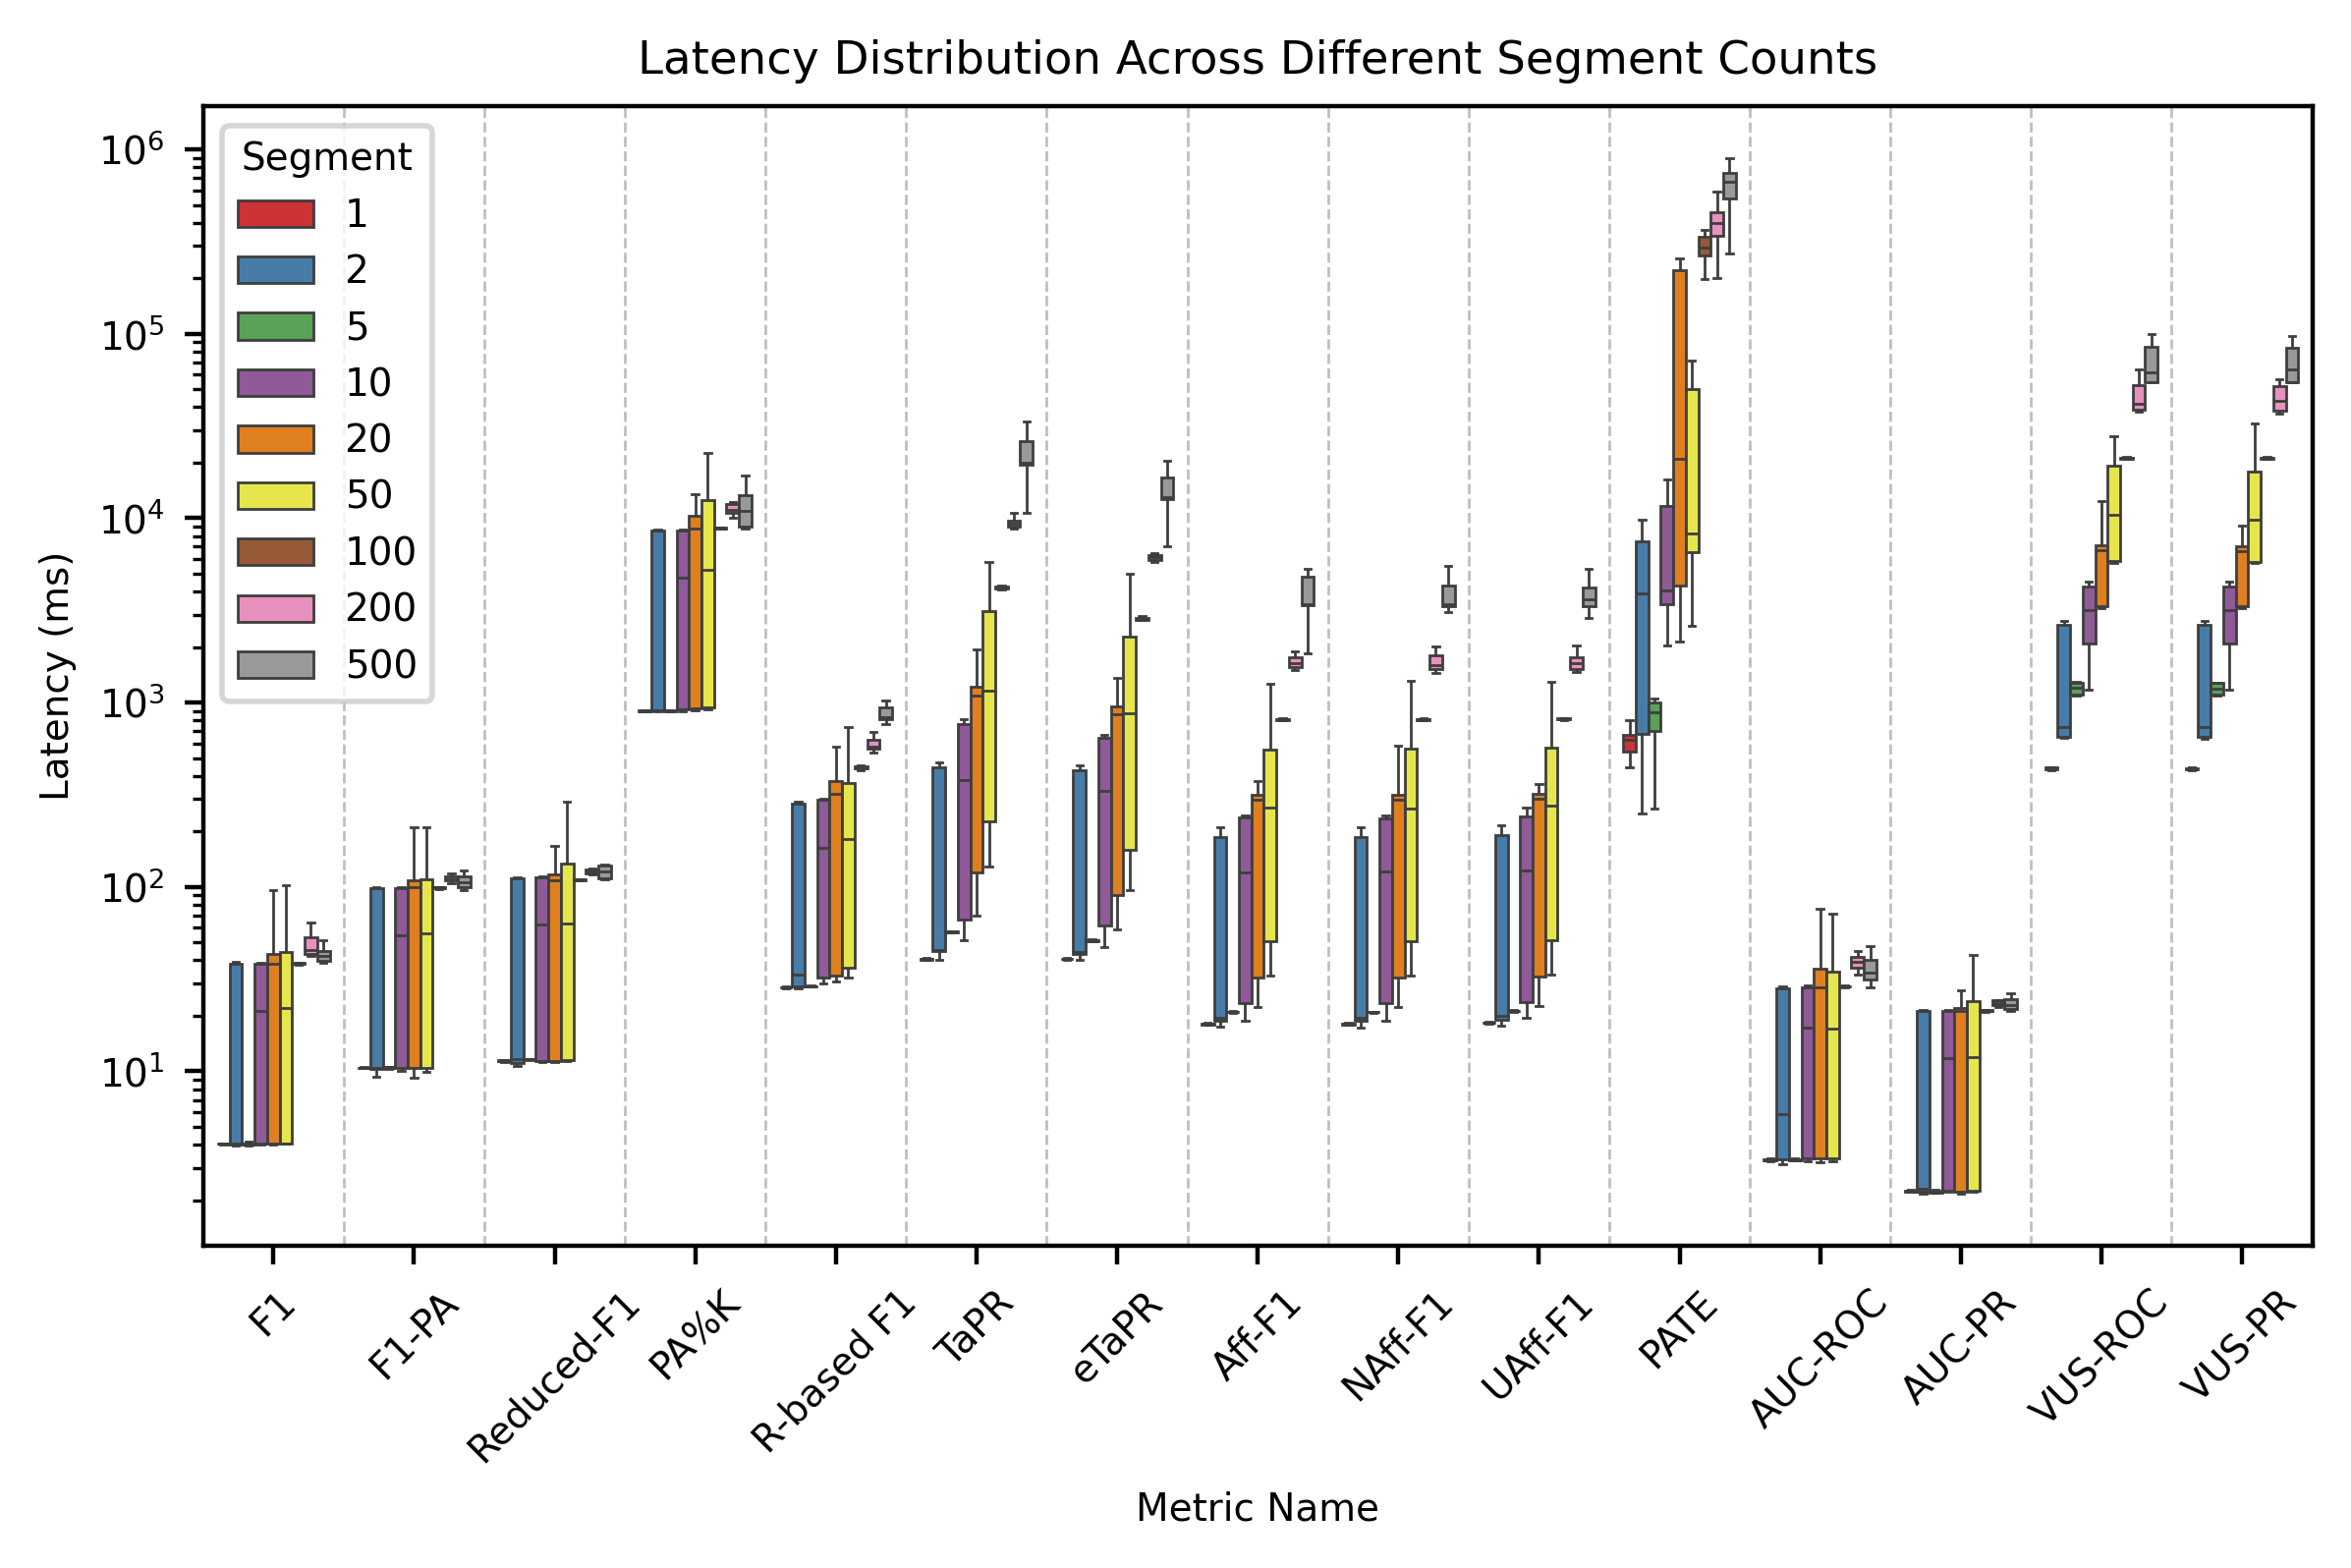

[100  10 200  20   2 500  50]


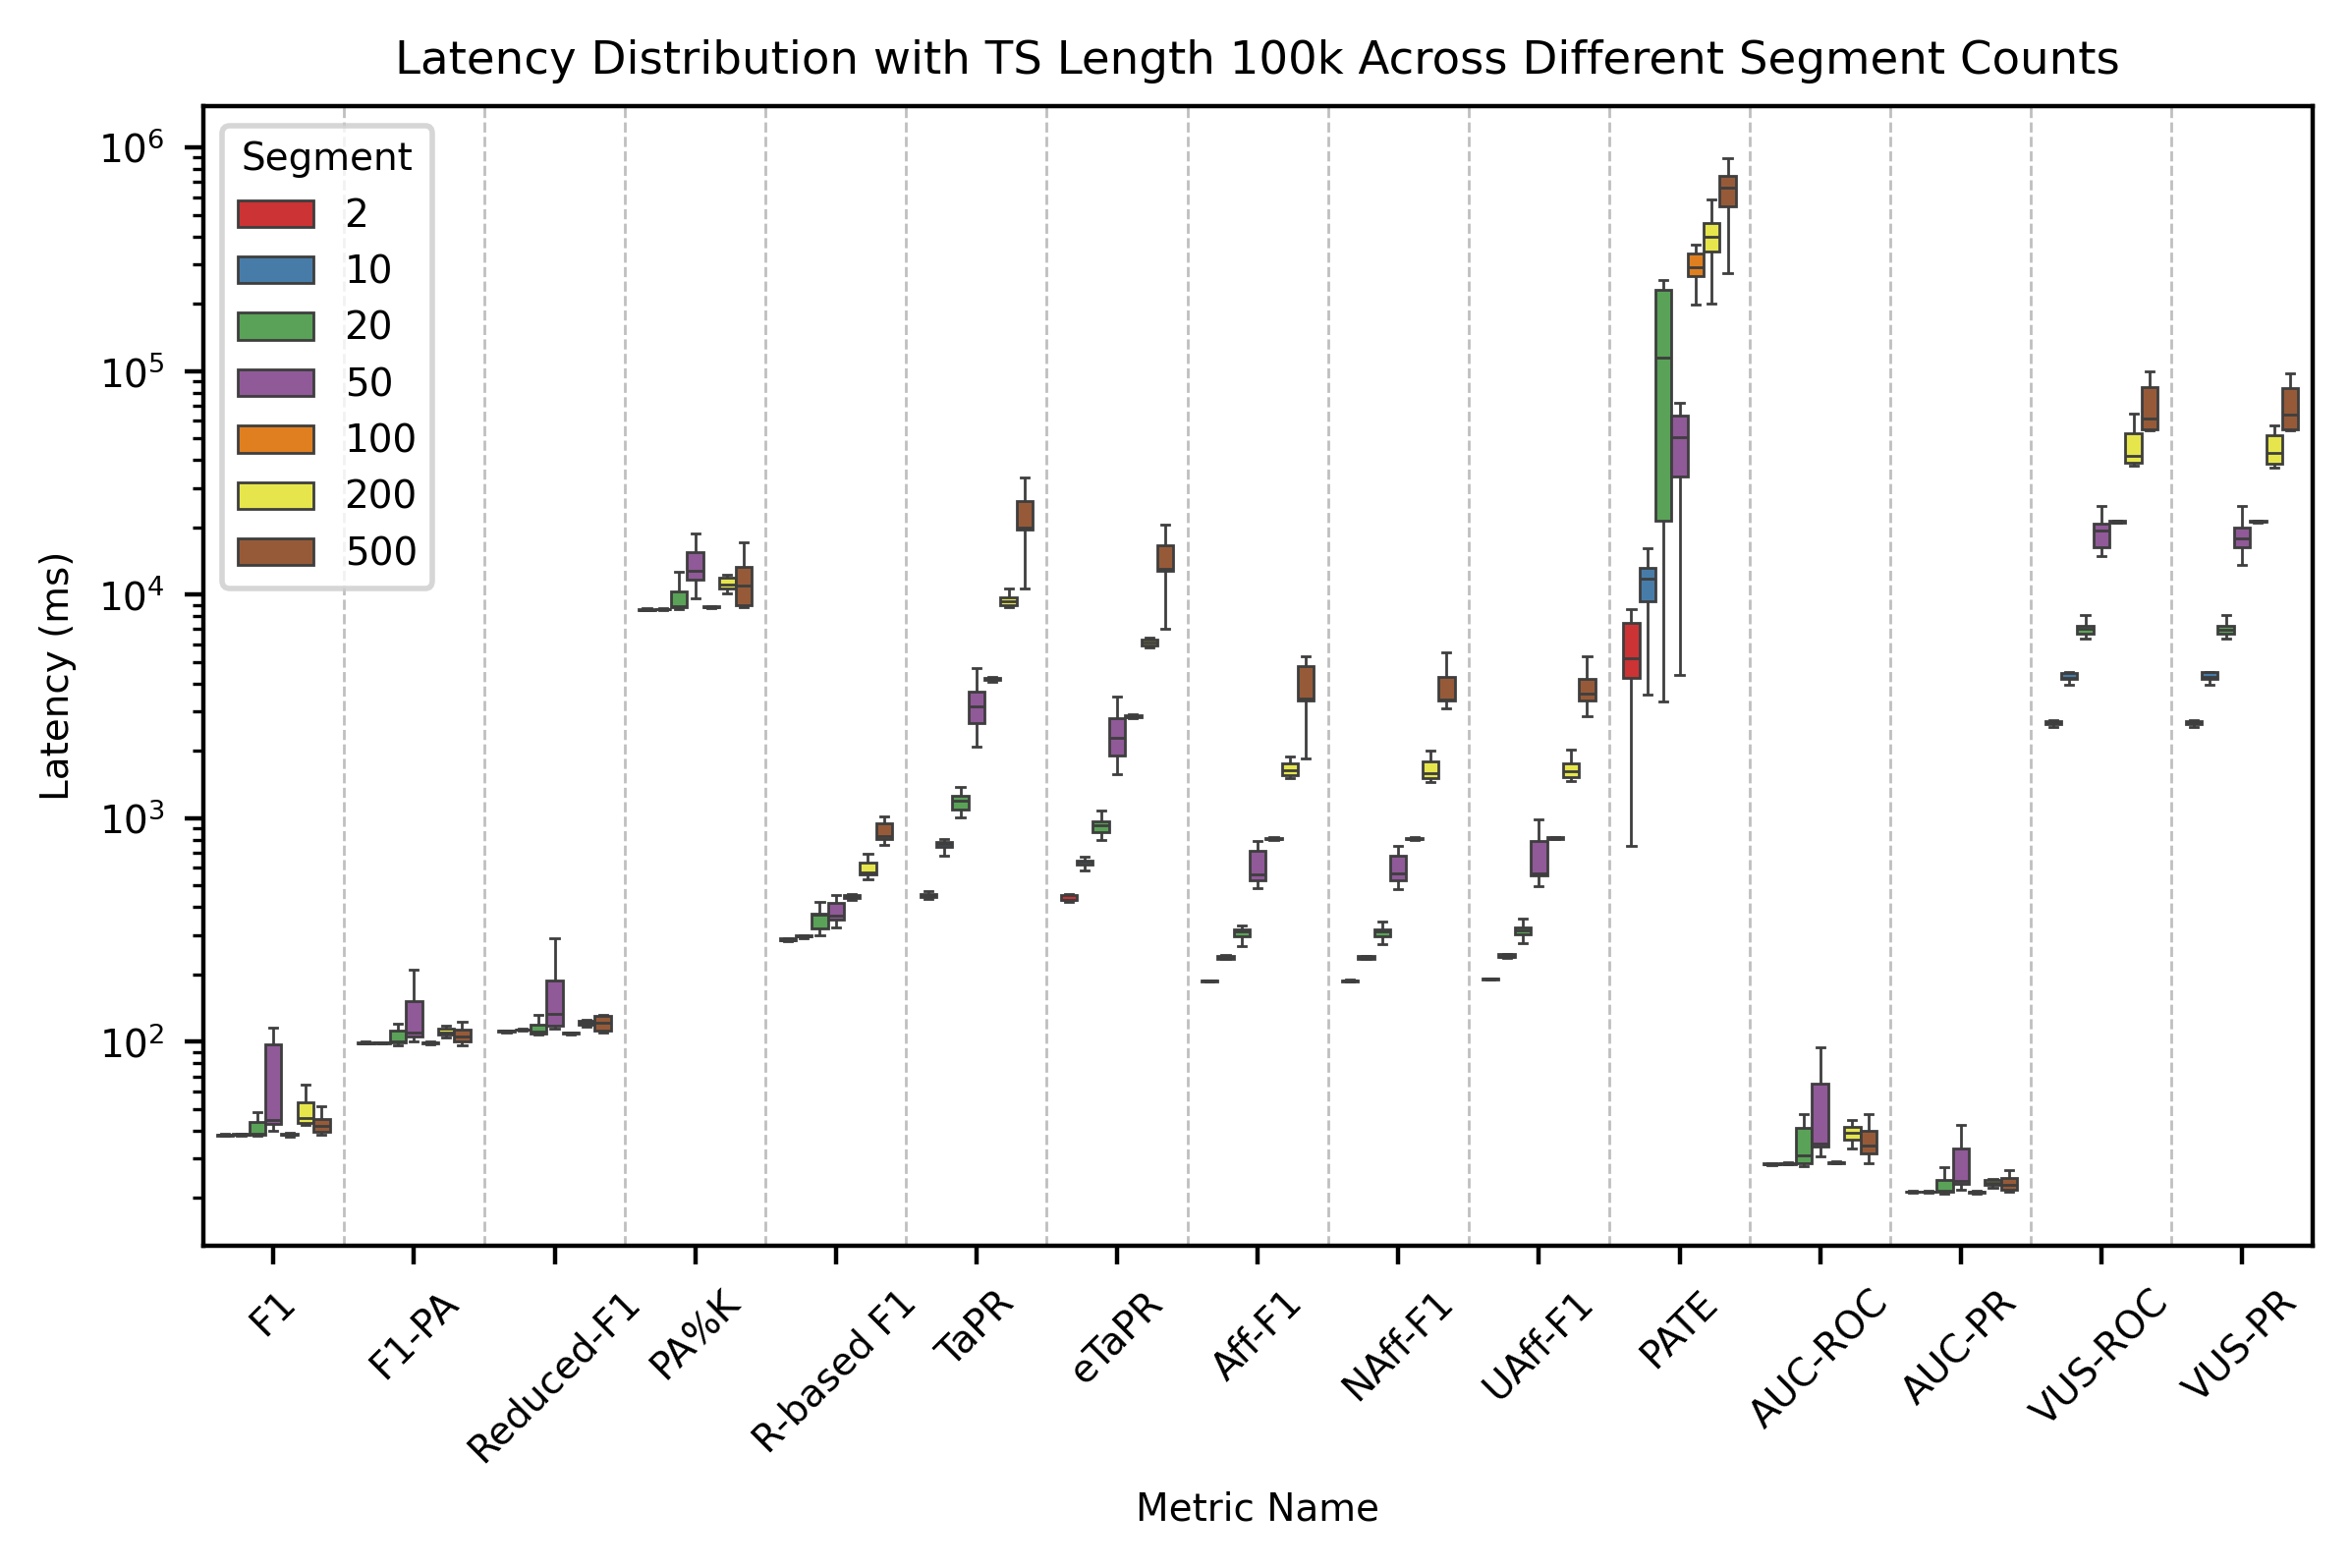

[10  1 20  2 50  5]


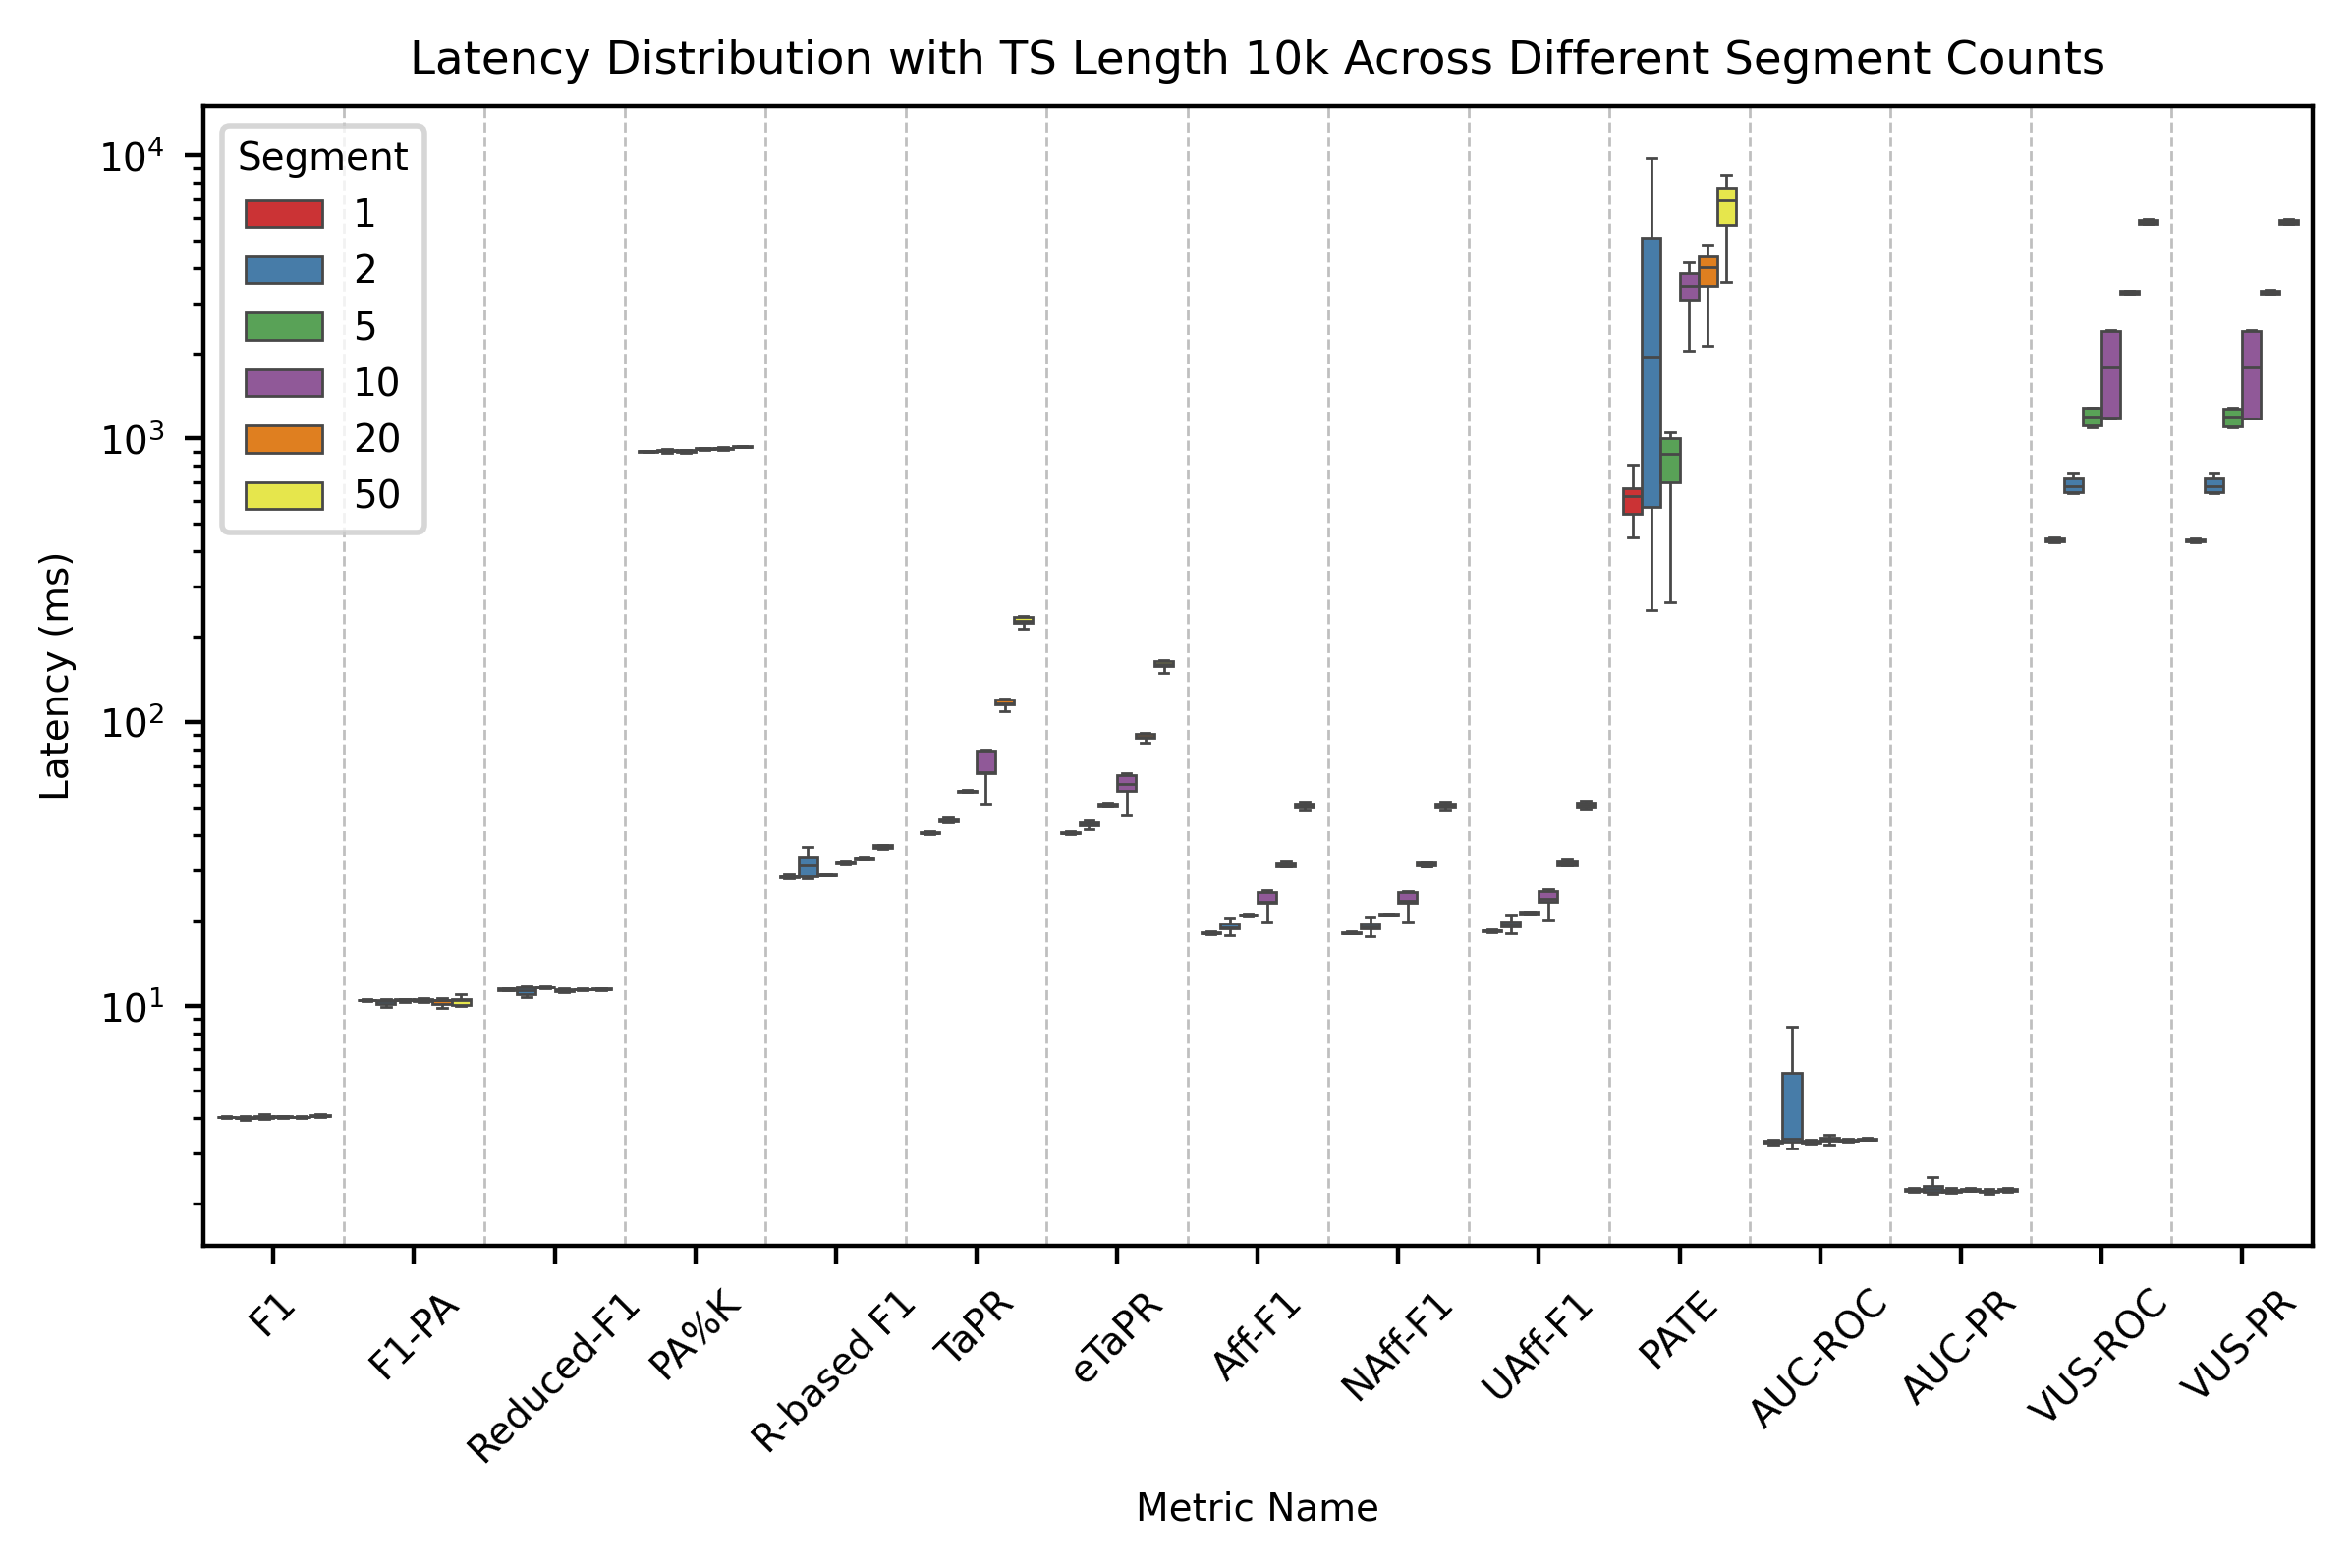

In [10]:
def plot_latency_distribution2(data_new, ts_len=None):
    df = data_new.copy()
    if ts_len is not None:
        df = df[df['ts_len'] == ts_len]

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    # delete nan
    # seg_list = [s for s in seg_list if pd.notna(s)]
    print(seg_list)
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort segments numerically
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
                # palette='Set2'  # END: Changed color palette
    # min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_latency'].agg(['min', 'max']).reset_index()
    # min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    # seg_list = df['seg'].unique()
    # seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 

    # min_max_ratios_max = min_max_ratios.groupby('metric_name')['ratio'].max().reset_index()
    # print(min_max_ratios_max)
    # for i, metric in enumerate(metric_sort):
    #     plt.annotate(
    #         f'Max Ratio: {min_max_ratios_max[min_max_ratios_max["metric_name"] == metric]["ratio"].values[0]:.2f}',
    #         xy=(i, 1.05),  # Adjust the y-coordinate for better visibility
    #         ha='center', va='bottom', fontsize=6, color='black'
    #     )
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Segment')
    if ts_len is not None:
        tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
        plt.title(f'Latency Distribution with TS Length {tmp} Across Different Segment Counts')
        tmp_name = f'_{tmp}'
    else:
        tmp_name = ''
        plt.title('Latency Distribution Across Different Segment Counts')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/seg_latency{tmp_name}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments
plot_latency_distribution2(data_new,100000)  # Plot for all segments
plot_latency_distribution2(data_new,10000)  # Plot for all segments


In [ ]:
def plot_latency_distribution_ts_len(data_new):
    df = data_new.copy()


    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['ts_len'].unique()
    # delete nan
    # seg_list = [s for s in seg_list if pd.notna(s)]
    print(seg_list)
    seg_list = sorted(seg_list)
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='ts_len', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Time Series Length')
    
    plt.title(f'Latency Distribution Across Different Time Series Lengths')
        
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/ts_len_latency.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution_ts_len(data_new)  # Plot for all segments



/tmp/ipykernel_3934153/1157008756.py:30: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name          mean           std
31           F1   Model100     52.997248     40.068102
32           F1    Model20     58.598654     44.327002
33           F1    Model30     41.947339      5.915430
34           F1    Model40     58.257661     54.475300
35           F1    Model50     43.666997     13.746027
..          ...        ...           ...           ...
122      VUS-PR    Model20  23213.130578  26685.246527
123      VUS-PR    Model30  21750.184043  21365.075907
124      VUS-PR    Model40  21035.634862  22766.772559
125      VUS-PR    Model50  20734.025664  21826.131761
126      VUS-PR    Model60  22651.109754  25237.438595

[150 rows x 4 columns]


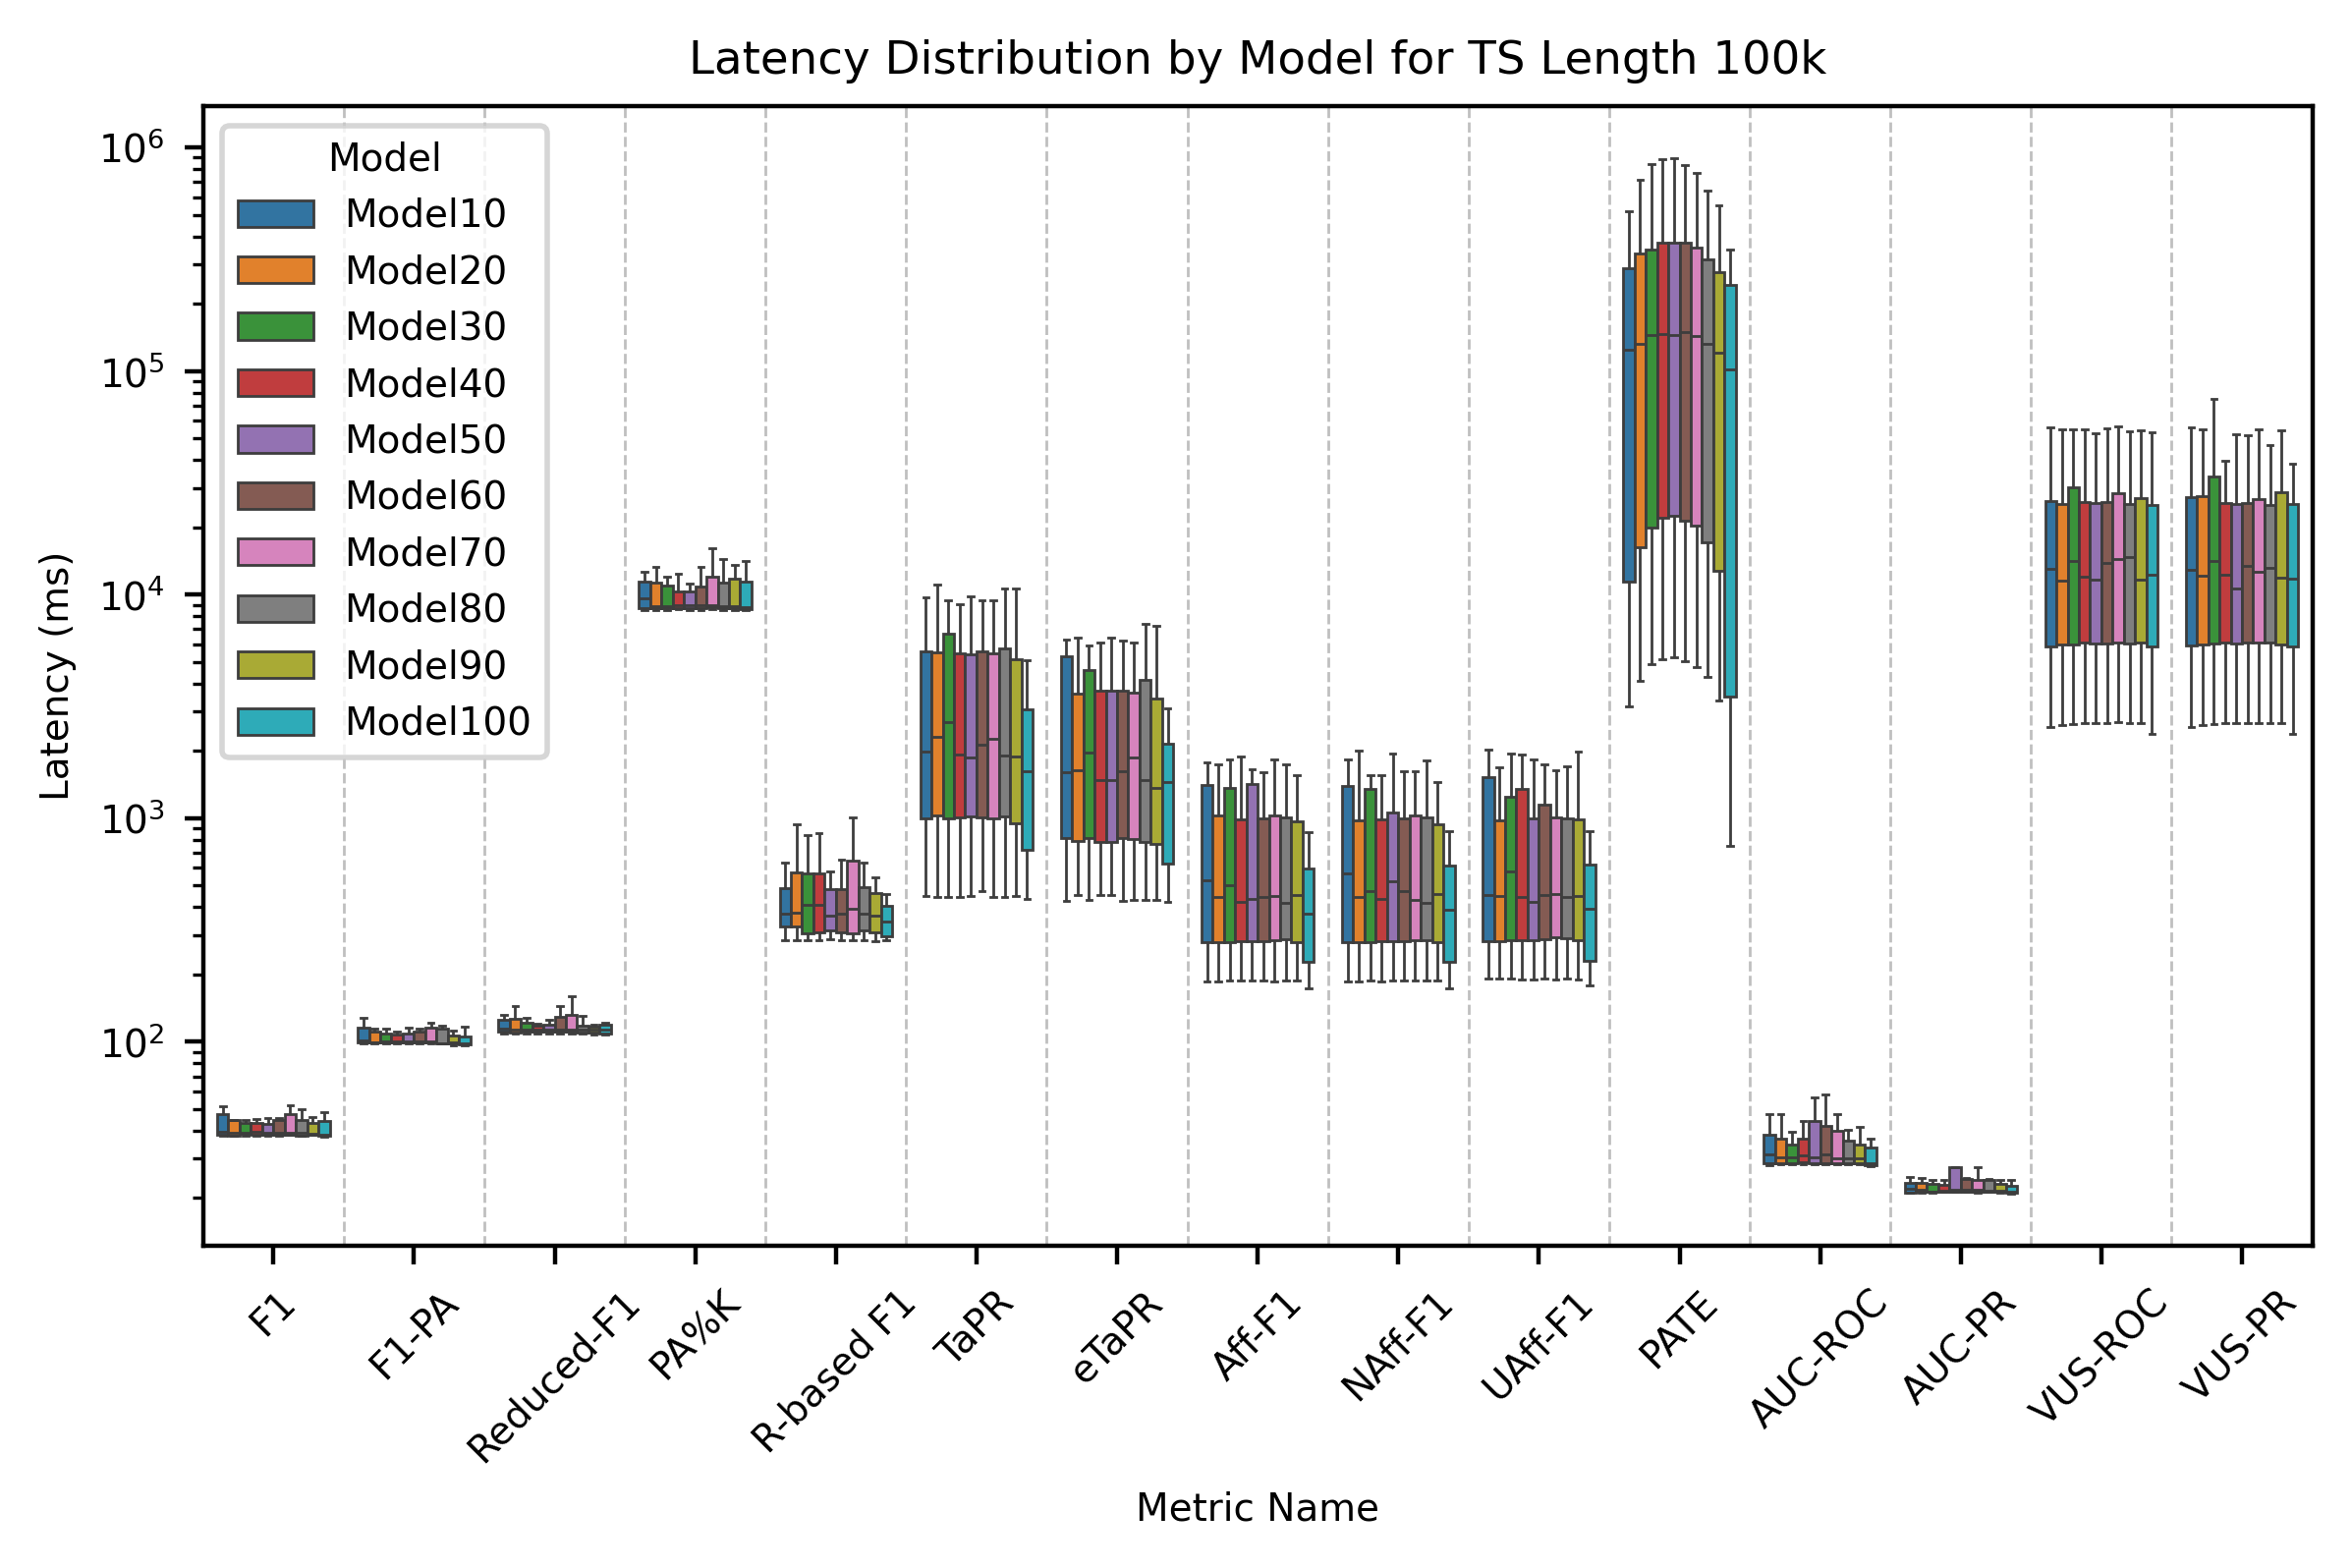

/tmp/ipykernel_3934153/1157008756.py:30: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name         mean          std
31           F1   Model100     4.012343     0.030686
32           F1    Model20     4.037299     0.029720
33           F1    Model30     4.052071     0.070582
34           F1    Model40     4.044138     0.025218
35           F1    Model50     4.047410     0.035531
..          ...        ...          ...          ...
122      VUS-PR    Model20  1989.406303  1887.693750
123      VUS-PR    Model30  1988.220715  1895.747336
124      VUS-PR    Model40  1987.356480  1890.001954
125      VUS-PR    Model50  1981.121821  1884.717266
126      VUS-PR    Model60  1987.272260  1892.517369

[150 rows x 4 columns]


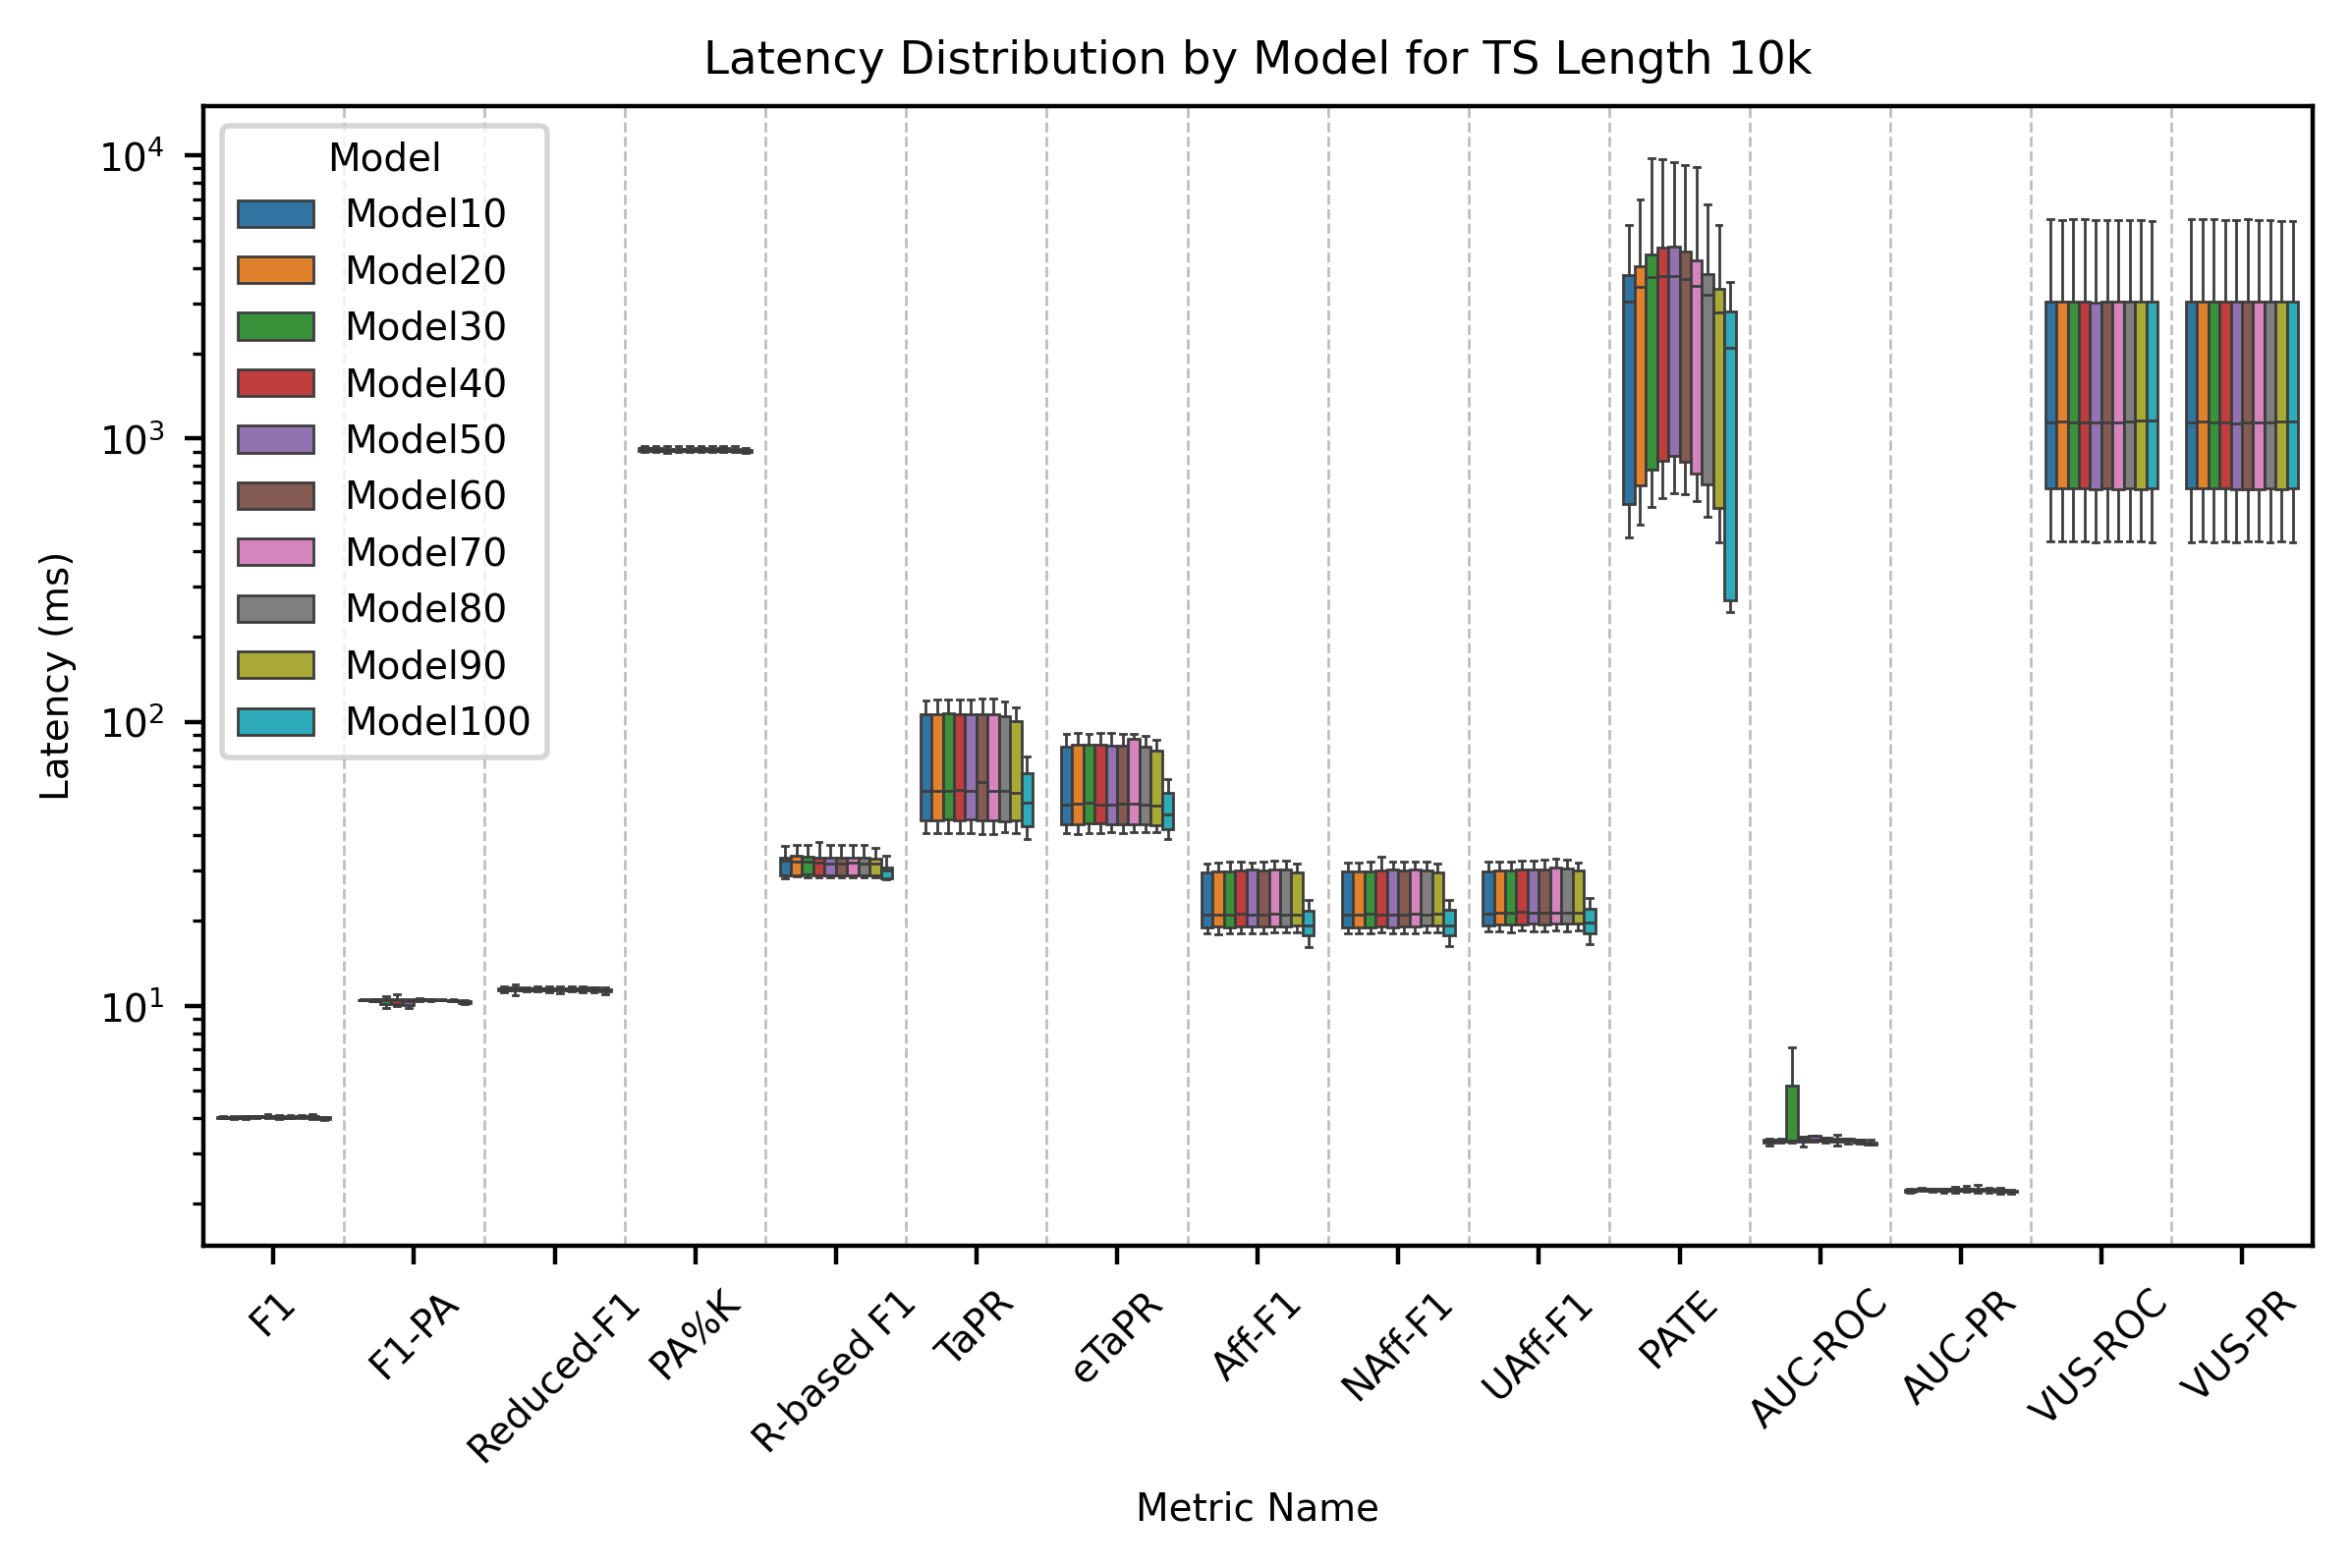

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_latency_distribution3(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        try:
            if tmp.startswith('Model'):
                num_part = tmp.split('Model')[-1]
                return int(num_part)
            else:
                return -float('inf')
        except:
            print(f"Error sorting model name: {tmp}")
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_latency'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Model')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution by Model for TS Length {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000